In [1]:
import torch
from torch.utils.data import DataLoader,Dataset
import os
from pathlib import Path
import pandas as pd
from torchvision.io import decode_png
from torchvision.transforms import v2
import torch.nn.functional as F
from torch import nn, optim 
import matplotlib.pyplot as plt
from scipy import ndimage
from torchvision import tv_tensors

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS")
    dl_workers = 0
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
    dl_workers = 4
else:
    device = torch.device("cpu")
    print("Using CPU")
    dl_workers = 4

Using MPS


In [3]:
import numpy as np
from scipy.ndimage import distance_transform_edt,binary_erosion,binary_dilation

def compute_weight_map(label,  w0=10, sigma=5):
    """Implementation kaggle / paper U-net"""
    foreground = (label  <1).astype(np.uint8)
    
    class_freq = np.bincount(label.flatten())
    wc = 1.0 / (class_freq[label] + 1e-6)  
    
    # Compute borders and distances
    eroded = binary_erosion(foreground)
    border = foreground - eroded
    d1 = distance_transform_edt(1 - border)  # Distance to nearest border
    d2 = distance_transform_edt(1 - binary_dilation(border))  # Distance to second nearest
    
    # Weight map
    border_weight = w0 * np.exp(- (d1 + d2)**2 / (2 * sigma**2))
    w = wc + border_weight
    return torch.tensor(w, dtype=torch.float32)


In [4]:
def get_win_coords(x,y, win_size,max_index):
    """Return window coordinates around given coordinates"""
    x_s, x_end = max(0, x - win_size), min(max_index, x + win_size)
    y_s, y_end = max(0, y - win_size), min(max_index, y + win_size)
    return x_s, x_end, y_s, y_end

def get_border_distance(boundary_image, pixel_labels, x, y, max_index, initial_win_size=5):
    """
    boundary_image: Image only containing boundaries of cells
    pixel_labels: Label of each pixel identifying different cells
    """
    win_size = initial_win_size
    
    while True:
        x_s, x_end, y_s, y_end = get_win_coords(x, y, win_size, max_index)
        label_patch = pixel_labels[y_s:y_end, x_s:x_end]
        uni = np.unique(label_patch)
        if uni.shape[0] <= 2:
            win_size += 5
        else:
            break
    
    patch = boundary_image[y_s:y_end, x_s:x_end]
    patch_boundaries = patch == 1
    boundary_pixel_coords = np.where(patch_boundaries)
    boundary_pixel_label_coords = np.where(label_patch > 0)
    boundary_pixel_labels = label_patch[boundary_pixel_label_coords]
    
    patch_center = (win_size, win_size)
    dst_x = boundary_pixel_coords[0] - patch_center[0]
    dst_y = boundary_pixel_coords[1] - patch_center[1]
    dist = np.sqrt(dst_x**2 + dst_y**2)
    
    l = list(zip(dist, zip(*boundary_pixel_coords), boundary_pixel_labels))
    l.sort()
    
    d_1, coord_1, lab_1 = l[0]
    d_2 = None
    for d, coord, lab in l[1:]:
        if lab != lab_1:
            d_2 = d
            break
    
    return d_1 + (d_2 if d_2 else d_1)

def compute_weight_map(label_image, w0=10, sigma=5, version=1):
    """Calculate weight map for U-Net training"""
    label_image = np.squeeze(np.array(label_image))
    max_index = label_image.shape[0] - 1
    
    tmp1 = label_image != 0
    struct = ndimage.generate_binary_structure(tmp1.ndim, tmp1.ndim)
    tmp2 = ndimage.binary_erosion(tmp1, struct, border_value=1)
    boundary_image = np.logical_xor(tmp1, tmp2)
    
    pixel_labels, _ = ndimage.label(boundary_image)
    
    weight_matrix = np.ones_like(label_image, dtype=np.float32)  # Start with 1.0 everywhere
    
    if version == 0:
        background_filt = tmp1 == False
        indices = np.where(background_filt)
    elif version == 1:
        tmp1_dil = ndimage.binary_dilation(tmp1, struct, border_value=1)
        blunt_edge_image = np.logical_xor(tmp1_dil, tmp2)
        indices = np.nonzero(blunt_edge_image)
    
    for y, x in zip(*indices):
        weight_matrix[y, x] = get_border_distance(boundary_image, pixel_labels, x, y, max_index)
    
    weight_matrix[indices] = w0 * np.exp(-((weight_matrix[indices])**2) / (2 * (sigma**2)))
    
    return torch.tensor(weight_matrix, dtype=torch.float32)

In [5]:
class UnetDataset(Dataset):

    def __init__(self,path,split:str, transform = None,padding:int | None = None,resized_shape:list[int] |None = None):
        self.img_dir = os.path.join(path,split,"imgs")
        self.label_dir = os.path.join(path,split,"labels")
        self.transform = transform
        self.padding = padding
        self.resized_shape = resized_shape

        self.imgs_names = sorted(os.listdir(self.img_dir))
        assert len(self.imgs_names) == len(sorted(os.listdir(self.label_dir))), f"Mismatch length in {split} between images and labels"

    def __len__(self):
        return len(self.imgs_names)
    
    def __getitem__(self,idx):
        if torch.is_tensor(idx):
            idx = idx.item()
        
        img_name = self.imgs_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name)
        img_png = open(img_path,"rb").read()    
        label_png = open(label_path,"rb").read()    
        img_tensor = torch.frombuffer(img_png, dtype=torch.uint8).clone()
        label_tensor = torch.frombuffer(label_png, dtype=torch.uint8).clone()
        
        image = decode_png(img_tensor)
        image = v2.functional.to_dtype(image,torch.float32, scale = True)
        label = decode_png(label_tensor)
    
        if self.resized_shape:
            image = v2.functional.resize(image,self.resized_shape)
            label = v2.functional.resize(label, self.resized_shape)

        if self.padding:
            image = v2.functional.pad(image, self.padding,fill = 0) 
            label = v2.functional.pad(label, self.padding,fill= 0) 

        label = tv_tensors.Mask(label)

        if self.transform:
            image,label = self.transform(image,label)

        if self.padding and self.resized_shape:
            label = v2.functional.center_crop(label, self.resized_shape)
            
        label = (label >=125).long() #binarize
        weight_map = compute_weight_map(label.numpy())

        return image, label.squeeze(0).long(),weight_map

class pairTransform:
    def __init__(self, transform_pipeline):
        self.transform_pipeline = transform_pipeline

    def __call__(self, image, label):
        if label.ndim == 2:
            label = label.unsqueeze(0)
            
        image, label = self.transform_pipeline(image, label)
        
        return image, label.squeeze(0)

In [6]:
#Transform

transform = v2.Compose(
    [v2.RandomRotation([-20,20]),v2.RandomVerticalFlip(),v2.RandomHorizontalFlip(),v2.ElasticTransform(interpolation=v2.InterpolationMode.NEAREST)]

)

/var/folders/sx/4l0cwz352hlg3_476mnfgfph0000gn/T/ipykernel_73980/3292826255.py:25: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:1587.)
  img_tensor = torch.frombuffer(img_png, dtype=torch.uint8).clone()


torch.Size([1, 1, 696, 696])
torch.Size([1, 696, 696])
torch.Size([1, 696, 696])
tensor([[0.0413, 0.3233, 2.5539,  ..., 0.0000, 0.0000, 0.0000],
        [0.0532, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 0.0000],
        [0.0532, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 0.0000],
        ...,
        [0.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 0.0000],
        [0.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]])


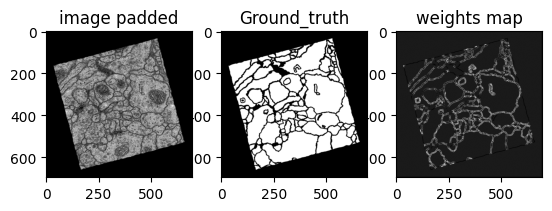

In [ ]:
cwd = Path.cwd().parent
path =os.path.join(cwd, "datas/Unet")
shape_orig = 512
shape_in = 572
shape_out = 388

pair_transform = pairTransform(transform)
# pair_transform = None
train_dataset = UnetDataset(path,split='train',transform=pair_transform)
test_dataset = UnetDataset(path,split='test',transform=pair_transform)
BATCH_SIZE = 1

train_loader = DataLoader(train_dataset,BATCH_SIZE, True, num_workers=dl_workers)
test_loader = DataLoader(test_dataset,BATCH_SIZE, True, num_workers=dl_workers)
plt.figure()
for images, masks,weights in train_loader:
    print(images.shape)
    print(masks.shape)
    print(weights.shape)
    plt.subplot(1,3,1) 
    plt.imshow(images[0,0], cmap="gray")
    plt.title("image padded")
    plt.subplot(1,3,2)
    plt.imshow(masks[0], cmap="gray")
    plt.title("Ground_truth")
    plt.subplot(1,3,3)
    plt.imshow(weights[0],"gray")
    plt.title("weights map")
    print(weights[0])
    break
plt.show()

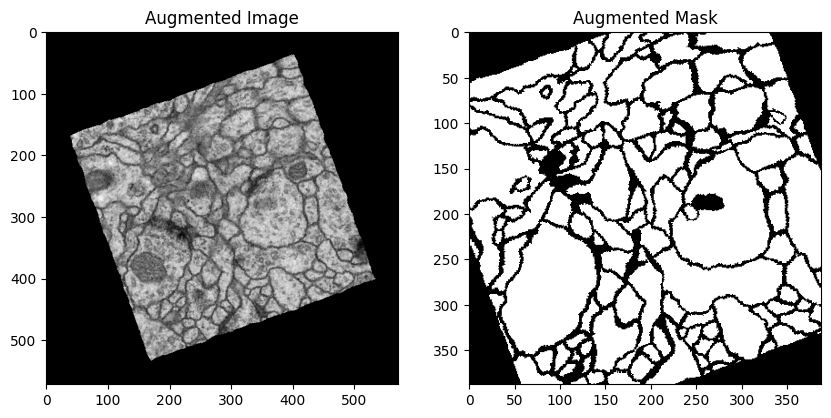

In [ ]:

ds = UnetDataset(path, split='train', transform=pair_transform, padding=92)
img, mask, _ = ds[0] 

# Display
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img[0], cmap='gray')
plt.title("Augmented Image")
plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Augmented Mask")
plt.show()

In [9]:
# 3D image visu
# import ndv
# ndv.imshow(images.numpy())

In [10]:
import sys
project_root = str(cwd)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from models.baseline_Unet import UNet, init_weights

# encode_in = (1, 64, 128, 256)
# encode_out = (64, 128, 256, 512)
# decode_in = (1024, 512, 256, 128)
# decode_out = (512, 256, 128, 64)
model = UNet(
        in_channels=1,
        num_classes=2,
        features=(64, 128, 256, 512),
        bilinear=False,
        normalize=True,
)
model.apply(init_weights)
model.to(device)

for img, _,_ in train_loader:
    img = img.to(device)
    out = model(img)
    print(out.shape)
    break

1
1
1
1
1
up_out_ch : 512
1
up_out_ch : 256
1
up_out_ch : 128
1
up_out_ch : 64
1
torch.Size([1, 2, 696, 696])


In [ ]:
class WeightedCrossEntropyLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.softmax = nn.Softmax(dim=1)      
    def forward(self, logits, targets, weights):
        probs = self.softmax(logits)  
        log_probs = torch.log(probs + 1e-10)  
        loss = -weights.unsqueeze(1) * log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        return loss.mean()
class PixelWiseEntropyLoss(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.loss_fn = nn.CrossEntropyLoss(reduction="none")
    def forward(self,logits,targets, weights):
        loss = self.loss_fn(logits,targets) * weights
        return loss.mean()
        
loss_fn = WeightedCrossEntropyLoss()
# optimizer = optim.SGD(model.parameters(),lr=0.01,momentum=0.99)
optimizer = optim.Adam(model.parameters(), lr = 1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma = 0.5)


Epoch 1, Step 0
Labels distribution - 0: 275673, 1: 208743
Logits mean: 1.226787, min: -41.326992, max: 43.689053
Probs class 0 mean: 0.352887, Probs class 1 mean: 0.647113
Weights - min: 0.0000, max: 9.6079, mean: 1.2294
Grad norm before clip: 14.891799, Loss: 2.659781
Epoch 1/10, Avg Loss: 1.207476

Epoch 2, Step 0
Labels distribution - 0: 271218, 1: 213198
Logits mean: 1.222448, min: -80.881584, max: 53.896332
Probs class 0 mean: 0.590699, Probs class 1 mean: 0.409301
Weights - min: 0.0000, max: 9.6079, mean: 1.3278
Grad norm before clip: 1.231735, Loss: 0.483847
Epoch 2/10, Avg Loss: 0.425924

Epoch 3, Step 0
Labels distribution - 0: 291558, 1: 192858
Logits mean: 0.998455, min: -34.051014, max: 20.190624
Probs class 0 mean: 0.602953, Probs class 1 mean: 0.397047
Weights - min: 0.0000, max: 9.6079, mean: 1.3197
Grad norm before clip: 0.428881, Loss: 0.421580
Epoch 3/10, Avg Loss: 0.379708

Epoch 4, Step 0
Labels distribution - 0: 290953, 1: 193463
Logits mean: 0.861398, min: -25.8

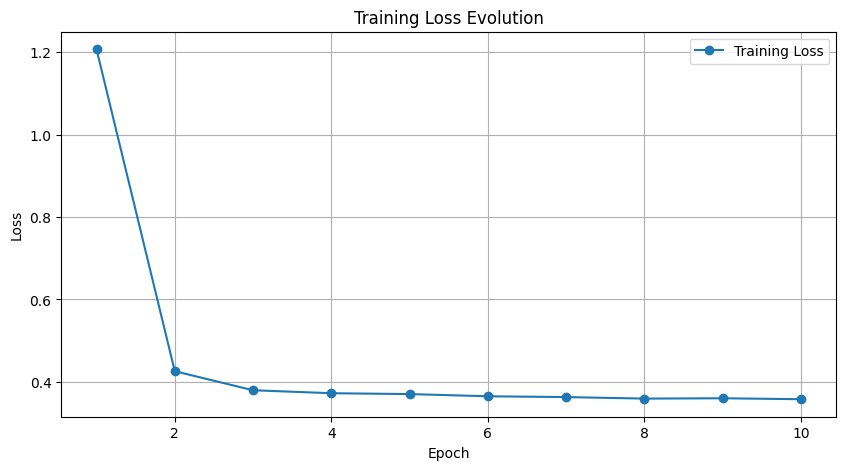

In [12]:

#Training
model.train()
num_epoch = 10
train_loss = []
for epoch in range(num_epoch):
    step = 0
    epoch_losses = []
    for images, labels, weights in train_loader:
        images, labels, weights = images.to(device), labels.to(device), weights.to(device)
        optimizer.zero_grad()
        out = model(images)

        if step == 0:
            probs = torch.softmax(out, dim=1)
            print(f"\nEpoch {epoch+1}, Step {step}")
            print(f"Labels distribution - 0: {(labels==0).sum().item()}, 1: {(labels==1).sum().item()}")
            print(f"Logits mean: {out.mean().item():.6f}, min: {out.min().item():.6f}, max: {out.max().item():.6f}")
            print(f"Probs class 0 mean: {probs[:, 0].mean().item():.6f}, Probs class 1 mean: {probs[:, 1].mean().item():.6f}")
            print(f"Weights - min: {weights.min().item():.4f}, max: {weights.max().item():.4f}, mean: {weights.mean().item():.4f}")

        loss = loss_fn(out, labels, weights)
        loss.backward()
        
        # Check gradient flow
        if step == 0:
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            print(f"Grad norm before clip: {grad_norm:.6f}, Loss: {loss.item():.6f}")
        else:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        epoch_losses.append(loss.item())
        step += 1
        
    # scheduler.step()

    avg_epoch_loss = np.mean(epoch_losses)
    train_loss.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}/{num_epoch}, Avg Loss: {avg_epoch_loss:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epoch + 1), train_loss, label='Training Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Evolution')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.eval()
test_loss = []
metric1 = []

with torch.no_grad():
    for images,labels, weights in test_loader:
        images,labels, weights = images.to(device),labels.to(device) ,weights.to(device)
        out = model(images)

        loss = loss_fn(out,labels,weights)
        test_loss.append(loss.item())

        prediction = torch.argmax(out,dim=1)
        intersection = ((prediction == 0) & (labels == 0)).sum()
        union = (prediction == 0).sum() + (labels == 0).sum()
        dice = (2 * intersection) / (union + 1e-8)
        metric1.append(dice.item())
avg_test_loss = np.mean(test_loss)
avg_dice = np.mean(metric1)
print(f"test loss:{avg_test_loss:.4f}, Dice: {avg_dice:.4f}" )


test loss:0.2833, Dice: 0.9061


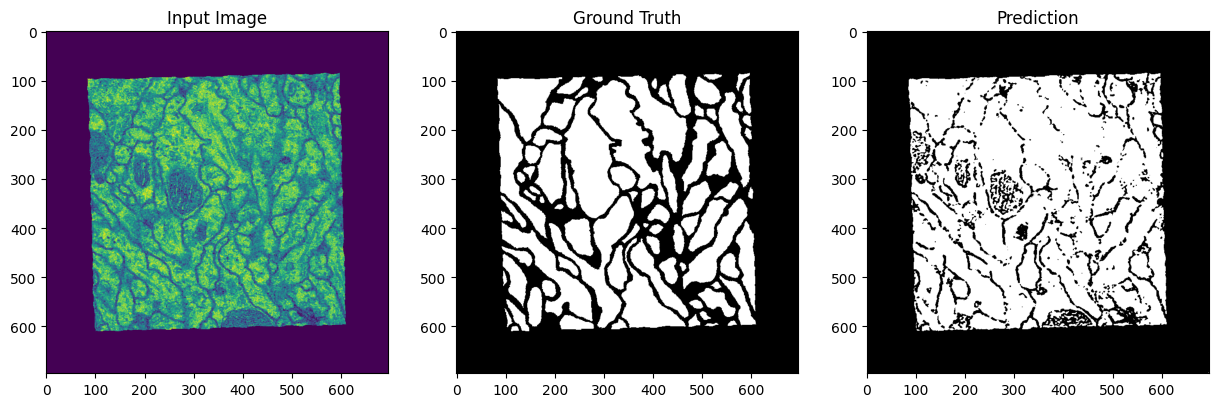

In [15]:
model.eval()
with torch.no_grad():
    for images, labels, _ in test_loader:
        images = images.to(device)
        out = model(images)
        preds = nn.functional.softmax(out, dim= 1)
        preds = torch.argmax(preds, dim=1).cpu()
        images = images.cpu()
        labels = labels.cpu()
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        ax[0].imshow(images[0,0])
        ax[0].set_title('Input Image')
        ax[1].imshow(labels[0].numpy(), cmap='gray')
        ax[1].set_title('Ground Truth')
        ax[2].imshow(preds[0].numpy(), cmap='gray')
        ax[2].set_title('Prediction')
        plt.show()
        break


In [16]:
torch.save(model.state_dict(), 'unet_model_1.pth')
